In [ ]:
pip install numpy scikit-learn matplotlib lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0cbdff253025c926ae05d389f17eb7a1d74c76a69102be68d24379ff6c7f4dcf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from lime.lime_tabular import LimeTabularExplainer


In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [ ]:
explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

In [ ]:
# Select one test sample
i = 1

In [ ]:
explanation = explainer.explain_instance(
    X_test[i],
    model.predict_proba
)


In [ ]:
print("\nLIME Explanation:")
for feature, weight in explanation.as_list():
    print(f"{feature} : {weight}")


LIME Explanation:
petal width (cm) <= 0.40 : -0.21114631496369868
petal length (cm) <= 1.70 : -0.17495568765012548
5.10 < sepal length (cm) <= 5.80 : 0.03585304623875255
sepal width (cm) > 3.30 : 0.0008971259275962553


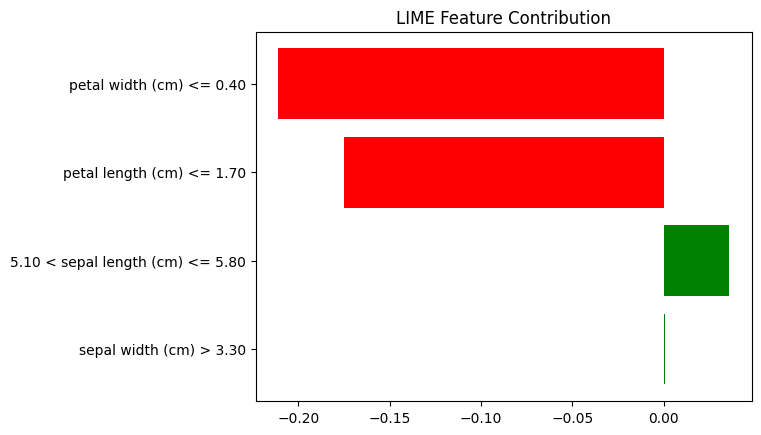

In [ ]:
fig = explanation.as_pyplot_figure()
plt.title("LIME Feature Contribution")
plt.show()